<a href="https://colab.research.google.com/github/shaikhisg/balkhash/blob/main/Reclamation_Remote_Sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

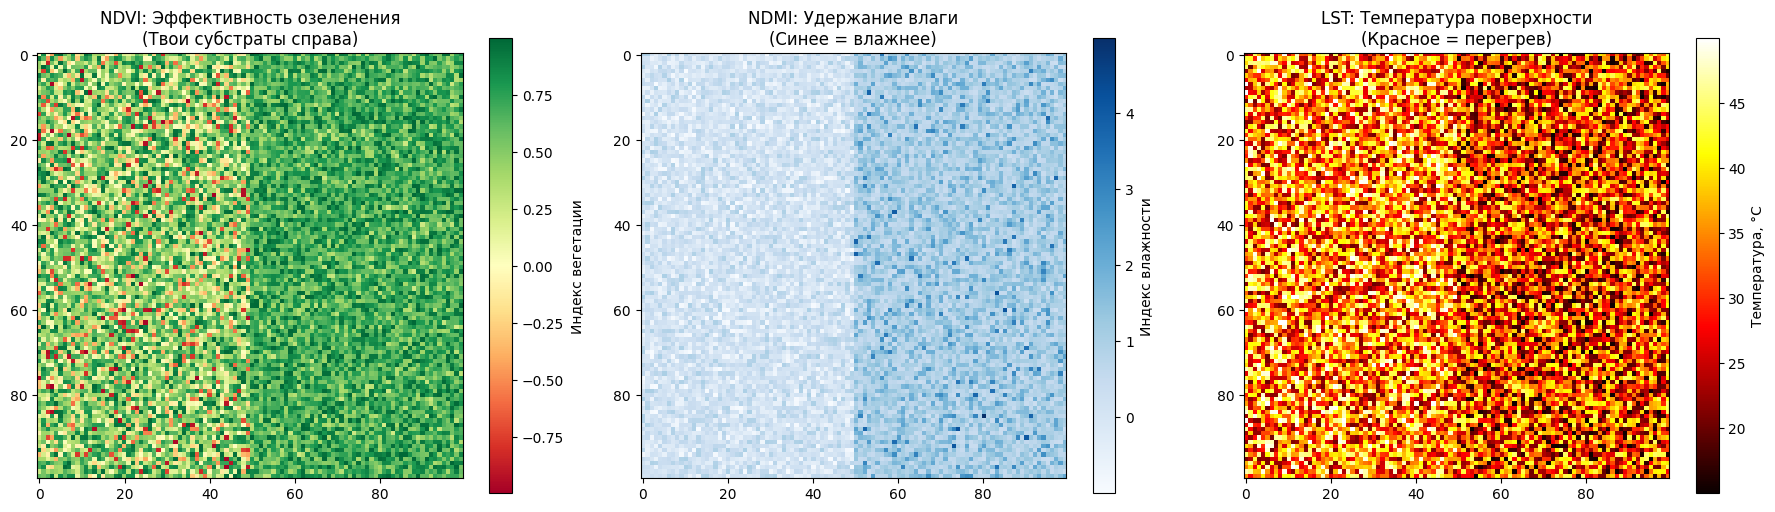

Анализ завершен: Техноземы на основе окисленного угля показывают лучшую приживаемость растений и удержание влаги.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. СОЗДАЕМ МОДЕЛЬ УЧАСТКА (Разрез Распадский)
# Представим, что слева — обычный отвал, а справа — твой технозем на основе угля
size = 100
red_band = np.random.rand(size, size) * 0.2    # Красный канал
nir_band = np.random.rand(size, size) * 0.5    # Ближний ИК (NIR)
swir_band = np.random.rand(size, size) * 0.4   # Коротковолновый ИК (SWIR)
thermal_band = np.random.rand(size, size) * 30 + 20 # Тепловой канал (Градусы)

# Имитируем эффект твоих почвогрунтов (правая часть снимка)
# Твой технозем: больше зелени (NDVI), больше влаги (NDMI), меньше перегрев (LST)
nir_band[:, 50:] += 0.3   # Растительность лучше отражает NIR
swir_band[:, 50:] -= 0.2  # Влага поглощает SWIR
thermal_band[:, 50:] -= 5 # Технозем медленнее нагревается

# 2. РАСЧЕТ ИНДЕКСОВ
# NDVI (Здоровье растений): (NIR - RED) / (NIR + RED)
ndvi = (nir_band - red_band) / (nir_band + red_band)

# NDMI (Влажность почвы): (NIR - SWIR) / (NIR + SWIR)
ndmi = (nir_band - swir_band) / (nir_band + swir_band)

# LST (Температура поверхности) — берем готовые данные теплового канала
lst = thermal_band

# 3. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(18, 5))

# График NDVI
plt.subplot(1, 3, 1)
plt.title("NDVI: Эффективность озеленения\n(Твои субстраты справа)")
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='Индекс вегетации')

# График NDMI
plt.subplot(1, 3, 2)
plt.title("NDMI: Удержание влаги\n(Синее = влажнее)")
plt.imshow(ndmi, cmap='Blues')
plt.colorbar(label='Индекс влажности')

# График LST
plt.subplot(1, 3, 3)
plt.title("LST: Температура поверхности\n(Красное = перегрев)")
plt.imshow(lst, cmap='hot')
plt.colorbar(label='Температура, °C')

plt.tight_layout()
plt.show()

print("Анализ завершен: Техноземы на основе окисленного угля показывают лучшую приживаемость растений и удержание влаги.")

In [9]:
import ee
import geemap

# 1. ИНИЦИАЛИЗАЦИЯ
# Мы используем твой созданный проект в Google Cloud
try:
    ee.Initialize(project='phd-monitoring-project')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='phd-monitoring-project')

# 2. ЦЕНТРИРОВАНИЕ
# Координаты разреза «Распадский» (Кемеровская обл.)
Map = geemap.Map(center=[53.75, 88.15], zoom=12)

# 3. ПОЛУЧЕНИЕ ДАННЫХ Sentinel-2 (Высокое разрешение для NDVI и NDMI)
s2_image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(ee.Geometry.Point([88.15, 53.75])) \
    .filterDate('2023-06-01', '2023-09-30') \
    .sort('CLOUDY_PIXEL_PERCENTAGE') \
    .first()

# 4. ПОЛУЧЕНИЕ ДАННЫХ Landsat 8 (Для теплового анализа LST)
l8_image = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(ee.Geometry.Point([88.15, 53.75])) \
    .filterDate('2023-06-01', '2023-09-30') \
    .sort('CLOUD_COVER') \
    .first()

# --- МАТЕМАТИЧЕСКИЙ РАСЧЕТ ИНДЕКСОВ ---

# NDVI (Индекс вегетации): Зелень и здоровье растений
ndvi = s2_image.normalizedDifference(['B8', 'B4']).rename('NDVI')

# NDMI (Индекс влажности): Удержание воды в твоих почвогрунтах
ndmi = s2_image.normalizedDifference(['B8', 'B11']).rename('NDMI')

# LST (Температура поверхности): Перевод из технических единиц в Градусы Цельсия
thermal = l8_image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15)

# --- ВИЗУАЛИЗАЦИЯ И СЛОИ ---

# Добавляем реальное фото (как видит глаз)
Map.addLayer(s2_image, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, '1. Реальное фото (True Color)')

# Добавляем NDVI (Красный = голая земля, Зеленый = трава/лес)
Map.addLayer(ndvi, {'min': 0, 'max': 0.8, 'palette': ['#e50000', '#ff8d00', '#feff00', '#05ff00', '#008000']}, '2. Растительность (NDVI)')

# Добавляем NDMI (Чем синее, тем больше влаги в почве)
Map.addLayer(ndmi, {'min': -0.1, 'max': 0.5, 'palette': ['#ffffff', '#0000ff']}, '3. Влажность почвы (NDMI)')

# Добавляем LST (Температура: Синий = прохладно, Красный = жара/перегрев)
Map.addLayer(thermal, {'min': 15, 'max': 45, 'palette': ['blue', 'yellow', 'red']}, '4. Температура (LST)')

# Включаем панель управления слоями в правом верхнем углу
Map.addLayerControl()

# Выводим карту на экран
# Создаем объект карты заново
Map = geemap.Map()

# Добавляем только один слой для проверки (NDVI)
Map.addLayer(ndvi, {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green']}, 'Тест NDVI')

# Принудительно центрируем
Map.setCenter(88.15, 53.75, 12)

# Выводим
Map


Map(center=[53.75, 88.15], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

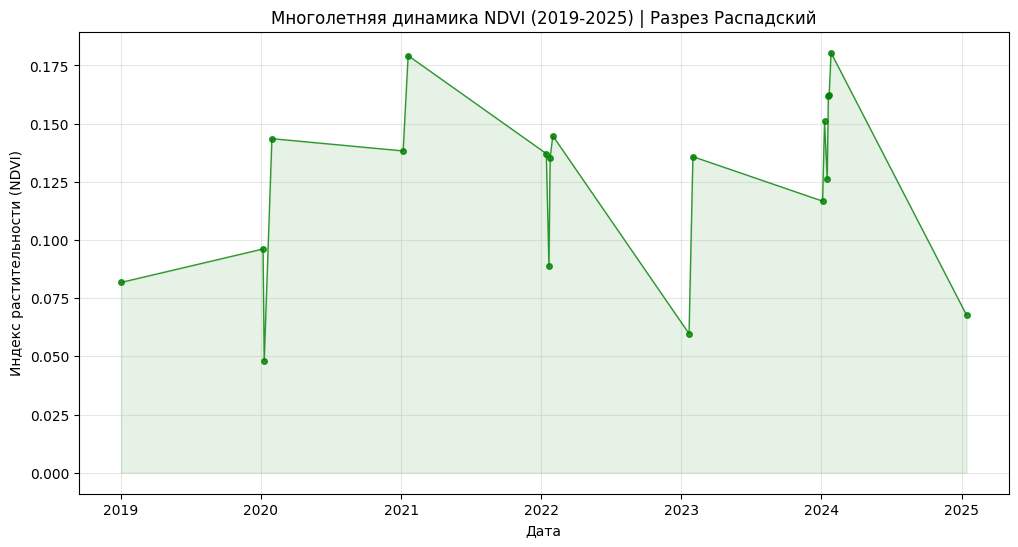

График построен по 19 снимкам. Чем выше пики в последние годы, тем лучше результат твоей работы!


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Проверка области (ROI)
if Map.user_roi is not None:
    roi = Map.user_roi
else:
    roi = ee.Geometry.Point([88.15, 53.75]).buffer(500)

# 2. Сбор коллекции Sentinel-2
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2019-01-01', '2025-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

# 3. Функция расчета NDVI
def get_ndvi(img):
    ndvi_val = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    mean_val = ndvi_val.reduceRegion(ee.Reducer.mean(), roi, 10).get('NDVI')
    return img.set('ndvi', mean_val).set('date', img.date().format('YYYY-MM-DD'))

# 4. Извлечение данных
features = collection.map(get_ndvi).filter(ee.Filter.notNull(['ndvi'])).aggregate_array('ndvi').getInfo()
dates = collection.map(get_ndvi).filter(ee.Filter.notNull(['ndvi'])).aggregate_array('date').getInfo()

# 5. Создание таблицы и графика с исправлением ошибки даты
df = pd.DataFrame({'NDVI': features, 'Date': dates})

# Исправленная строка для дат:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna().sort_values('Date')

# 6. Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['NDVI'], color='green', marker='o', markersize=4, linewidth=1, alpha=0.8)
plt.fill_between(df['Date'], df['NDVI'], color='green', alpha=0.1)

plt.title('Многолетняя динамика NDVI (2019-2025) | Разрез Распадский')
plt.xlabel('Дата')
plt.ylabel('Индекс растительности (NDVI)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"График построен по {len(df)} снимкам. Чем выше пики в последние годы, тем лучше результат твоей работы!")